In [1]:
# -----------------------------
# Setup
# -----------------------------
import numpy as np
import pandas as pd
import re
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

In [2]:
# -----------------------------
# Load Datasets
# -----------------------------
variants_data = pd.read_csv("losAlomosData4ML.csv")
variants_data_full = variants_data
#variants_data.head()
stanford_muts = pd.read_csv('data/Stanford-resistance-comments.csv')
stanford_mut_list = set(stanford_muts['Mutation'])
variants_data.shape

variants_data = variants_data.loc[:, ~variants_data.columns.str.contains(r'[\*\-]')]
print(variants_data.shape)

target = 'Status'
test_size = 0.2
pos_label = 'yes'
perc_top_features = 0.01 #we analyse the top 1% mutations
gene = 'IN'
algor_colors = ["#6082B6","#2AAA8A","#E3963E"]
y = variants_data[[target]].values.ravel()

# get rid of mixture mutations

drop_vars = ['Status','Year', 'Subtype', 'Georegion']
#drop_vars = ['Status']#,'Sample']

pure_mutation_pattern = r'^[A-Z][0-9]+[A-Z]$'

mixed_variants_data = variants_data.loc[:, ~variants_data.columns.str.match(pure_mutation_pattern)]
variants_data = variants_data.loc[:, variants_data.columns.str.match(pure_mutation_pattern)]

(41247, 8118)


In [3]:
rf_muts = ['S283G', 'T112V', 'D278A', 'K136Q', 'T125A', 'V201I', 'V31I', 'T124A',
          'I72V', 'L101I', 'K14R', 'E11D', 'A265V', 'G134N', 'T124N', 'D167E',
          'D256E', 'T206S', 'S17N', 'I135V']

rf_muts.append('Status')
df5 = variants_data_full[rf_muts]
df5['Status'].value_counts()

# Function to perform Fisher's Exact test on each column against 'status'
def fisher_exact_tests_with_proportions(df, status_col='Status'):
    results = []

    for col in df.columns:
        if col == status_col:
            continue

        # Create a 2x2 contingency table
        contingency_table = pd.crosstab(df[col], df[status_col])
        #print(contingency_table)
        # Perform Fisher's Exact test
        _, p_value = fisher_exact(contingency_table)

        # Get the counts for each level in the status column
        count_00 = contingency_table.iloc[0, 0]  # Count for col=0, status=0
        count_01 = contingency_table.iloc[0, 1]  # Count for col=0, status=1
        count_10 = contingency_table.iloc[1, 0]  # Count for col=1, status=0
        count_11 = contingency_table.iloc[1, 1]  # Count for col=1, status=1
        
        # Calculate total counts for proportions
        total_status_0 = count_00 + count_10  # Total for status=0
        total_status_1 = count_01 + count_11  # Total for status=1

        # Calculate proportions
        prop_10 = count_10 / total_status_0 
        prop_11 = count_11 / total_status_1 
        
        # overall prevalence
        count_mut_present =  count_10 + count_11
        overall_prop = count_mut_present /(count_00 + count_01 + count_10 + count_11)

        # Append results with proportions
        results.append({
            'Column': col,
            'P-value': p_value,
            'Total Naive': total_status_0,
            'Total Treated': total_status_1,
            'Count Naive': count_10,
            'Count Treated': count_11,
            'Naive': prop_10,
            'Treated': prop_11,
            'Overall count': count_mut_present,
            'Overall prev': overall_prop
        })

    return pd.DataFrame(results)

# Example usage
# Replace with your actual DataFrame
# df = pd.read_csv('your_file.csv')
df_results = fisher_exact_tests_with_proportions(df5)

print(df_results)

   Column        P-value  Total Naive  Total Treated  Count Naive  \
0   S283G   0.000000e+00        19762          21485         2673   
1   T112V   0.000000e+00        19762          21485         2167   
2   D278A   0.000000e+00        19762          21485          649   
3   K136Q   0.000000e+00        19762          21485         1237   
4   T125A   0.000000e+00        19762          21485         5973   
5   V201I   0.000000e+00        19762          21485         9358   
6    V31I  9.991097e-196        19762          21485         6032   
7   T124A   0.000000e+00        19762          21485         4411   
8    I72V   4.326793e-73        19762          21485         6186   
9   L101I   7.185025e-53        19762          21485        10303   
10   K14R   0.000000e+00        19762          21485         2157   
11   E11D   1.678901e-92        19762          21485         6308   
12  A265V  3.974887e-223        19762          21485         1758   
13  G134N   0.000000e+00        19

In [4]:
df_results.to_csv('top20mutationsRf.csv')

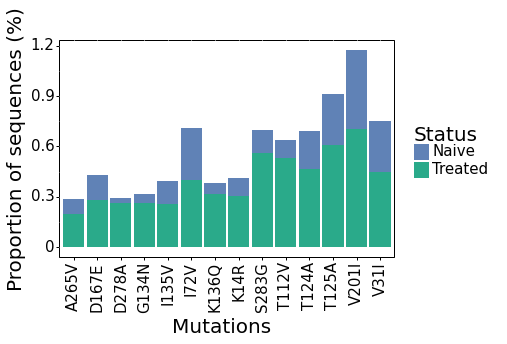

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 10 x 5 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: potential-new-drms-rf.png


In [5]:
# Assume df_results is already computed from the previous code
# Step 1: Subset the DataFrame
subset_results = df_results[df_results['Treated'] > df_results['Naive']]

# Step 2: Create a bar graph using Plotnine
# Melt the DataFrame to long format for plotting
subset_long = pd.melt(subset_results, id_vars=['Column'], 
                      value_vars=['Naive', 'Treated'], 
                      var_name='Status', value_name='Proportion')

# Create the bar plot
plot = (ggplot(subset_long, aes(x='Column', y='Proportion', fill='Status')) 
        + geom_bar(stat="identity")#, position='dodge')
    + theme(panel_background=element_rect(fill='white'),
            panel_border=element_rect(color='black',size=1),
            axis_text_x=element_text(color='black', size=15, angle=90),
            axis_text_y=element_text(color='black', size=15),
            axis_title=element_text(color='black', size=20),
            legend_text=element_text(color='black', size=15),
            legend_title=element_text(color='black', size=20),
            strip_text=element_text(color='black',size=20),
            strip_background=element_rect(color='black', fill="white"))
        +scale_fill_manual(values = algor_colors)
  #  +coord_flip()
    +theme(legend_position="right")
    + ylab('Proportion of sequences (%)')
    + xlab('Mutations'))

# Display the plot
print(plot)
plot.save("potential-new-drms-rf.png", width=10, height=5, dpi=300)

In [6]:
stanford_muts_instis = stanford_muts[stanford_muts.Drugclass == 'INSTI'].copy()
stanford_muts_major = stanford_muts_instis[stanford_muts_instis['Comment/ Mutation Type'] == 'Major'].copy()
major_drms = stanford_muts_major['Mutation']

identified_muts = variants_data.columns.intersection(major_drms)
identified_muts
major_drms_df = variants_data_full[identified_muts]
major_drms_df.shape

(41247, 33)

In [7]:
new_muts_df = variants_data_full[subset_results['Column'].values]
new_muts_df.shape

(41247, 14)

In [8]:
# Function to calculate Relative Risk
def calculate_relative_risk(major_drms_df, new_muts_df):
    results = []

    # Iterate through each major DRM mutation
    for major_col in major_drms_df.columns:
        # Iterate through each new mutation
        for new_col in new_muts_df.columns:
            # Create a contingency table
            contingency_table = pd.DataFrame({
                'Major_DRM': major_drms_df[major_col],
                'New_Mut': new_muts_df[new_col]
            })

            # Calculate the counts
            counts = contingency_table.value_counts().unstack(fill_value=0)
            
            # Ensure the contingency table has the correct shape
            if counts.shape == (2, 2):
                # Calculate Relative Risk
                a = counts.loc[1, 1]  # Major DRM present, New Mutation present
                b = counts.loc[1, 0]  # Major DRM present, New Mutation absent
                c = counts.loc[0, 1]  # Major DRM absent, New Mutation present
                d = counts.loc[0, 0]  # Major DRM absent, New Mutation absent
                
                # Calculate the risks
                risk_major_drm = a / (a + b) if (a + b) > 0 else 0
                risk_new_mut = c / (c + d) if (c + d) > 0 else 0
                
                # Calculate Relative Risk (RR)
                rr = risk_major_drm / risk_new_mut if risk_new_mut > 0 else None
                
                # Store results
                results.append({
                    'Major_DRM': major_col,
                    'New_Mutation': new_col,
                    'RR': rr
                })

    return pd.DataFrame(results)

# Calculate Relative Risk
rr_results = calculate_relative_risk(major_drms_df, new_muts_df)

# Display results
print(rr_results)

    Major_DRM New_Mutation        RR
0       E138A        S283G  0.097240
1       E138A        T112V  0.176325
2       E138A        D278A  0.228057
3       E138A        K136Q  0.178278
4       E138A        T125A  0.702519
..        ...          ...       ...
457     Y143S         K14R  0.354643
458     Y143S        A265V  0.171073
459     Y143S        G134N  0.076610
460     Y143S        D167E  0.401484
461     Y143S        I135V  0.559875

[462 rows x 3 columns]


In [9]:
major_col='G140R'
new_col='I135V'

In [10]:
contingency_table = pd.DataFrame({
                major_col: major_drms_df[major_col],
                new_col: new_muts_df[new_col]
            })

# Calculate the counts
counts = contingency_table.value_counts().unstack(fill_value=0)

In [11]:
counts

I135V,0,1
G140R,,
0,32874,8230
1,92,51


In [12]:
a = counts.loc[1, 1]  # Major DRM present, New Mutation present
b = counts.loc[1, 0]  # Major DRM present, New Mutation absent
c = counts.loc[0, 1]  # Major DRM absent, New Mutation present
d = counts.loc[0, 0]  # Major DRM absent, New Mutation absent

In [13]:
contingency_table

,G140R,I135V
0,0,0
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
41242,0,1
41243,0,1
41244,0,0
41245,0,0


In [14]:
rr_with_drm=a/(a+b)
rr_without_drm=c/(c+d)
rr = rr_with_drm/rr_without_drm
rr

1.781223393860089

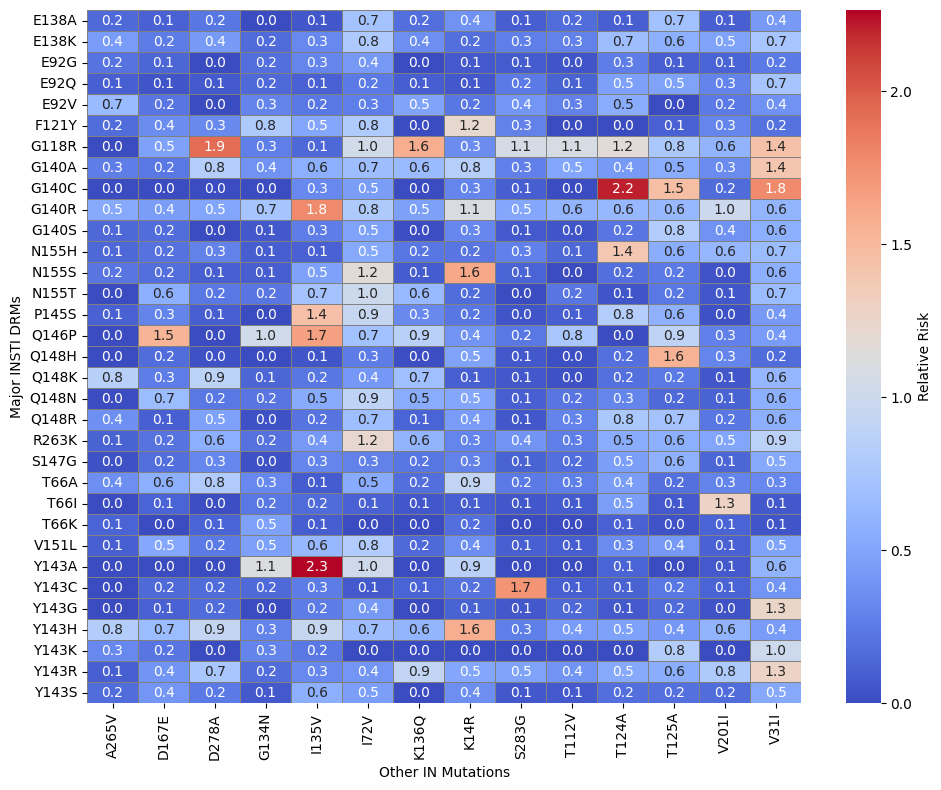

In [15]:
heatmap_data = rr_results.pivot(index='Major_DRM',
                                columns='New_Mutation',
                                values='RR')

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",                     # 👈 THIS controls decimal places
    cmap='coolwarm',
    cbar_kws={'label': 'Relative Risk'},
    linewidths=0.5,
    linecolor='grey'
)

plt.ylabel('Major INSTI DRMs')
plt.xlabel('Other IN Mutations')

plt.tight_layout()
plt.savefig("Relative-risk-potential-major-rf.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
stanford_muts_instis = stanford_muts[stanford_muts.Drugclass == 'INSTI'].copy()
stanford_muts_acc = stanford_muts_instis[stanford_muts_instis['Comment/ Mutation Type'] == 'Accessory'].copy()
stanford_muts_acc_ = stanford_muts_acc['Mutation']

identified_muts = variants_data.columns.intersection(stanford_muts_acc_)
muts_cols = list(identified_muts) + ['Status']

In [17]:
# List of characters to match
# acc_drms = variants_data_full[muts_cols]
# acc_drms.

In [18]:
# Calculate Relative Risk
#acc_rr_results = calculate_relative_risk(acc_drms, new_muts_df)

# Display results
#print(acc_rr_results)

In [19]:
# heatmap_data_acc = acc_rr_results.pivot(index='Major_DRM',
#                                 columns='New_Mutation',
#                                 values='RR')

# plt.figure(figsize=(12, 10))

# sns.heatmap(
#     heatmap_data,
#     annot=True,
#     fmt=".1f",                     # 👈 THIS controls decimal places
#     cmap='coolwarm',
#     cbar_kws={'label': 'Relative Risk'},
#     linewidths=0.5,
#     linecolor='grey'
# )

# plt.ylabel('Accessory INSTI DRMs')
# plt.xlabel('Other IN Mutations')

# plt.tight_layout()
# plt.savefig("Relative-risk-potential-acc-rf.png", dpi=300, bbox_inches='tight')
# plt.show()


In [73]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_relative_risk(major_drms_df, new_muts_df):
    results = []
    
    for major_col in major_drms_df.columns:
        for new_col in new_muts_df.columns:
            
            contingency_table = pd.DataFrame({
                'Major_DRM': major_drms_df[major_col],
                'New_Mut': new_muts_df[new_col]
            })
            
            counts = contingency_table.value_counts().unstack(fill_value=0)
            
            if counts.shape == (2, 2):
                a = counts.loc[1, 1]  # DRM+, RAM+
                b = counts.loc[1, 0]  # DRM+, RAM-
                c = counts.loc[0, 1]  # DRM-, RAM+
                d = counts.loc[0, 0]  # DRM-, RAM-
                
                risk_major_drm = a / (a + b) if (a + b) > 0 else 0
                risk_new_mut = c / (c + d) if (c + d) > 0 else 0
                
                # Relative Risk
                rr = risk_major_drm / risk_new_mut if risk_new_mut > 0 else None
                
                # --- 95% CI for RR (Wald log method) ---
                if rr and rr > 0 and a > 0 and b > 0 and c > 0 and d > 0:
                    log_rr = np.log(rr)
                    se_log_rr = np.sqrt((1/a) - (1/(a+b)) + (1/c) - (1/(c+d)))
                    ci_lower = np.exp(log_rr - 1.96 * se_log_rr)
                    ci_upper = np.exp(log_rr + 1.96 * se_log_rr)
                else:
                    ci_lower, ci_upper = None, None
                
                # --- p-value (Fisher's Exact Test) ---
                contingency_matrix = np.array([[a, b], [c, d]])
                _, p_value = stats.fisher_exact(contingency_matrix)
                
                results.append({
                    'Major_DRM': major_col,
                    'New_Mutation': new_col,
                    'a (DRM+/RAM+)': a,
                    'b (DRM+/RAM-)': b,
                    'c (DRM-/RAM+)': c,
                    'd (DRM-/RAM-)': d,
                    'RR': round(rr, 3) if rr else None,
                    'CI_lower': round(ci_lower, 3) if ci_lower else None,
                    'CI_upper': round(ci_upper, 3) if ci_upper else None,
                    'p_value': round(p_value, 4)
                })
    
    df = pd.DataFrame(results)
    
    # --- FDR correction (Benjamini-Hochberg) ---
    from statsmodels.stats.multitest import multipletests
    valid = df['p_value'].notna()
    df.loc[valid, 'p_adjusted'] = multipletests(
        df.loc[valid, 'p_value'], method='fdr_bh'
    )[1].round(4)
    
    return df

# Run
rr_results = calculate_relative_risk(major_drms_df, new_muts_df)

# Filter RR >= 1.5 AND statistically significant
filtered = rr_results[
    (rr_results['RR'] >= 1.5) & 
    (rr_results['p_adjusted'] < 0.05) &
    (rr_results['CI_lower'] > 1.0)  # CI does not cross 1
]

print(filtered)

    Major_DRM New_Mutation  a (DRM+/RAM+)  b (DRM+/RAM-)  c (DRM-/RAM+)  \
86      G118R        D278A             20             48           6279   
87      G118R        K136Q             21             47           8036   
118     G140C         V31I             21             10          15626   
119     G140C        T124A             24              7          14454   
139     G140R        I135V             51             92           8230   
177     N155S         K14R             43             83           8669   
228     Q148H        T125A            271            108          18833   
377     Y143A        I135V             10             12           8271   
378     Y143C        S283G             73             45          14696   

     d (DRM-/RAM-)     RR  CI_lower  CI_upper  p_value  p_adjusted  
86           34900  1.929     1.334     2.790   0.0034      0.0049  
87           33143  1.583     1.108     2.259   0.0304      0.0386  
118          25590  1.787     1.401     2.

In [75]:
#filtered.to_csv('filtered_relative_risk.csv')
rr_results.to_csv('unfiltered_relative_risk.csv')

In [76]:
import pandas as pd

# Example threshold
rr_threshold = 1.5

#rr_filtered = rr_results#[rr_results["RR"] >= rr_threshold].copy()
#rr_filtered = rr_results[rr_results["RR"] >= rr_threshold].copy()
rr_filtered = filtered

In [77]:
import networkx as nx

G = nx.Graph()

# Add major DRM nodes
for drm in rr_filtered["Major_DRM"].unique():
    G.add_node(drm, type="major")

# Add new mutation nodes
for mut in rr_filtered["New_Mutation"].unique():
    G.add_node(mut, type="putative")

# Add weighted edges
for _, row in rr_filtered.iterrows():
    G.add_edge(
        row["Major_DRM"],
        row["New_Mutation"],
        weight=row["RR"]
    )

In [78]:
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:10]

[('I135V', 4.047),
 ('G140C', 3.995),
 ('G118R', 3.512),
 ('Y143A', 2.266),
 ('T124A', 2.208),
 ('D278A', 1.929),
 ('V31I', 1.787),
 ('G140R', 1.781),
 ('Y143C', 1.731),
 ('S283G', 1.731)]

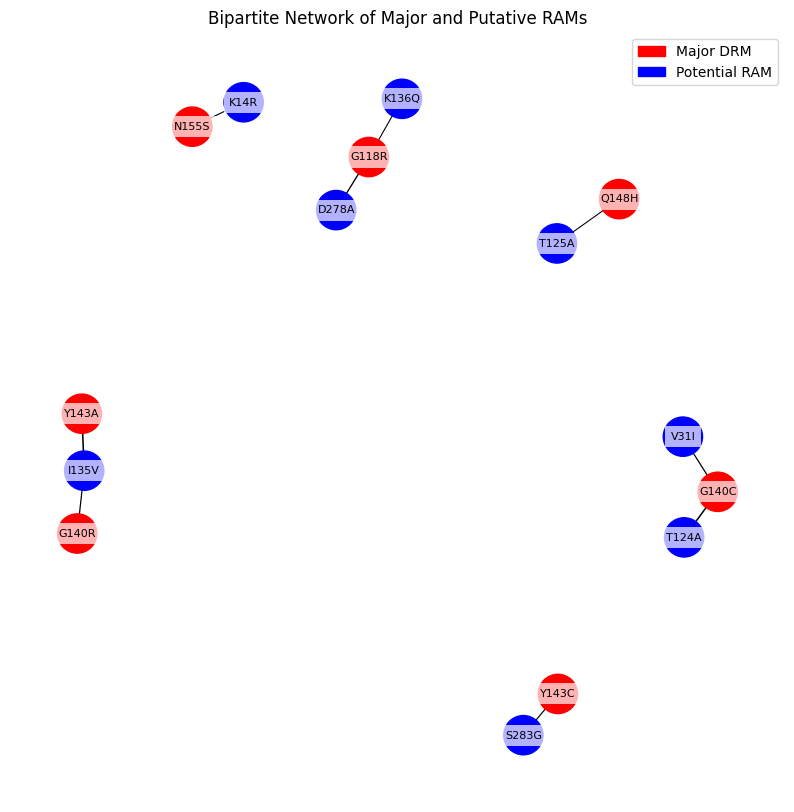

In [81]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

pos = nx.spring_layout(G, k=0.5, seed=42)

node_colors = [
    "red" if G.nodes[n]["type"] == "major" else "blue"
    for n in G.nodes()
]

edge_widths = [G[u][v]["weight"] / 2 for u, v in G.edges()]

plt.figure(figsize=(10,10))

# Draw nodes and edges (no labels yet)
nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors,
                       node_size=800)

nx.draw_networkx_edges(G, pos,
                       width=edge_widths)

# Draw readable labels with white background
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

# Legend
major_patch = mpatches.Patch(color='red', label='Major DRM')
putative_patch = mpatches.Patch(color='blue', label='Potential RAM')
plt.legend(handles=[major_patch, putative_patch], loc='best')

plt.title("Bipartite Network of Major and Putative RAMs")
plt.axis("off")
plt.savefig("Bipartite-network-filtered-on-CI.png", dpi=300, bbox_inches='tight')
plt.show()